# Amputation Coordination Analysis

Analyses the effect of front-leg (T1L) amputation on walking coordination in fruit flies.
Compares 0-day and 7-day post-amputation conditions across multiple flies.

**Pipeline:**
- Input: `data3D.csv` from JARVIS `fly44_l` predictions (44 keypoints, T1L amputated)
- Walking bout detection adapted for 5 intact legs (T1L_TaTip absent)
- Fall detection via head-Z dip prominence
- Phase coordination analysis with circular statistics
- 0d vs 7d group comparison throughout

**T1L amputation note:** Only `T1L_ThxCx` (coxa base) is present. All distal T1L joints are absent.

## Section 0 — Imports & Configuration

In [1]:
# Cell 0a: Imports
from pathlib import Path
import csv
import json
import yaml
from typing import List, Dict, Tuple, Optional
import numpy as np
import pandas as pd
import scipy
from scipy.signal import find_peaks, hilbert
from scipy.ndimage import uniform_filter1d, gaussian_filter1d
from scipy.stats import sem, circmean, circstd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.collections import LineCollection
from matplotlib.patches import Patch

mpl.rcParams.update({
    'pdf.fonttype': 42,
    'pdf.use14corefonts': True,
    'font.family': 'sans-serif',
    'axes.spines.right': False,
    'axes.spines.top': False,
})

print("Imports loaded.")


Imports loaded.


In [2]:
# Cell 0b: Configuration — edit this dict to set all parameters
CFG = {
    # --- Input paths ---
    # Add one entry per fly per condition.
    # Each path should be the Predictions_3D_.../ folder containing data3D.csv
    "paths_0d": [
        "/home/user/src/JARVIS-HybridNet/projects/fly44_l_V4/predictions/predictions3D/Predictions_3D_20260210-063709/", #Session7/2025_10_13_15_02_19/
        "/home/user/src/JARVIS-HybridNet/projects/fly44_l_V4/predictions/predictions3D/Predictions_3D_20260212-032455/", #Session2/2025_10_08_16_35_26/
        "/home/user/src/JARVIS-HybridNet/projects/fly44_l_V4/predictions/predictions3D/Predictions_3D_20260213-081351/", #Session2/2025_10_08_17_21_07/
        "/home/user/src/JARVIS-HybridNet/projects/fly44_l_V4/predictions/predictions3D/Predictions_3D_20260212-061802/",# Session2/2025_10_08_17_55_41/
        "/home/user/src/JARVIS-HybridNet/projects/fly44_l_V4/predictions/predictions3D/Predictions_3D_20260212-090838/",#Session2/2025_10_08_18_06_20/
        "/home/user/src/JARVIS-HybridNet/projects/fly44_l_V4/predictions/predictions3D/Predictions_3D_20260212-122657/", # Session2/2025_10_08_18_33_14/
        "/home/user/src/JARVIS-HybridNet/projects/fly44_l_V4/predictions/predictions3D/Predictions_3D_20260212-141448/", #Session2/2025_10_08_18_44_28/
        "/home/user/src/JARVIS-HybridNet/projects/fly44_l_V4/predictions/predictions3D/Predictions_3D_20260212-165505/", #Session2/2025_10_08_18_54_48/
        "/home/user/src/JARVIS-HybridNet/projects/fly44_l_V4/predictions/predictions3D/Predictions_3D_20260212-203919/", #Session2/2025_10_08_19_06_09/
        # "/path/to/fly2_0d/Predictions_3D_.../",
    ],
    "paths_7d": [
        "/home/user/src/JARVIS-HybridNet/projects/fly44_l_V4/predictions/predictions3D/Predictions_3D_20260211-064849/", #Session2/2025_10_08_14_22_43/
        "/home/user/src/JARVIS-HybridNet/projects/fly44_l_V4/predictions/predictions3D/Predictions_3D_20260211-085656/", #Session2/2025_10_08_14_33_23/
        "/home/user/src/JARVIS-HybridNet/projects/fly44_l_V4/predictions/predictions3D/Predictions_3D_20260211-130159/",  #Session2/2025_10_08_14_55_58/
        "/home/user/src/JARVIS-HybridNet/projects/fly44_l_V4/predictions/predictions3D/Predictions_3D_20260211-164547/", #Session2/2025_10_08_15_07_37/
        "/home/user/src/JARVIS-HybridNet/projects/fly44_l_V4/predictions/predictions3D/Predictions_3D_20260211-195348/", #Session2/2025_10_08_15_32_54/
        "/home/user/src/JARVIS-HybridNet/projects/fly44_l_V4/predictions/predictions3D/Predictions_3D_20260211-233843/", #Session2/2025_10_08_15_45_31/
        '/home/user/src/JARVIS-HybridNet/projects/fly44_l_V4/predictions/predictions3D/Predictions_3D_20260228-094637',
        '/home/user/src/JARVIS-HybridNet/projects/fly44_l_V4/predictions/predictions3D/Predictions_3D_20260228-150914',
        '/home/user/src/JARVIS-HybridNet/projects/fly44_l_V4/predictions/predictions3D/Predictions_3D_20260228-040755',
        '/home/user/src/JARVIS-HybridNet/projects/fly44_l_V4/predictions/predictions3D/Predictions_3D_20260227-221454',
        '/home/user/src/JARVIS-HybridNet/projects/fly44_l_V4/predictions/predictions3D/Predictions_3D_20260227-171621'
# "/path/to/fly1_7d/Predictions_3D_.../",
    ],

    # --- Data loading ---
    "jarvis_scale": 10.0,   # raw CSV units → mm
    "fps": 800,
    "confidence_threshold": 0.8,
    "conf_gap_bridge": 15,  # frames

    # --- Walking bout detection ---
    "min_walking_cycles": 2,           # per leg (intact legs only)
    "min_body_displacement_mm": 3.0,
    "min_bout_duration_frames": 400,
    "immobility_speed_mm_s": 2.0,
    "immobility_max_frames": 25,
    "max_immobility_gap_frames": 100,  # gap-bridging tolerance for bout continuity
    "max_swing_duration": 35,          # frames; upper width limit for swing peak
    "swing_prominence": 0.05,          # mm

    # --- Phase detection (velocity threshold — used for swing/stance binary) ---
    "swing_velocity_threshold_mm_s": 10.0,
    "swing_smooth_sigma": 1.5,

    # --- Hilbert phase ---
    "smooth_sigma": 6,                 # Gaussian sigma (frames) for 3-D speed before Hilbert

    # --- Fall detection ---
    "fall_prominence_mm": 0.25,         # min depth of head-Z dip to count as fall
    "fall_min_duration_frames": 20,    # min width of dip (frames)
    "fall_head_keypoints": ["Antenna_Base", "EyeL", "EyeR"],

    # --- Floor Z filter ---
    "floor_z_threshold_mm": 0.40,

    # --- Upright filter ---
    "upright_filter_enabled": True,

    # --- Keypoints (do NOT change unless model changes) ---
    "intact_leg_tips": ["T1R_TaTip", "T2L_TaTip", "T2R_TaTip", "T3L_TaTip", "T3R_TaTip"],
    "stump_kp": "T1L_ThxCx",
    "scutellum_kp": "Scutellum",
    "head_kps": ["Antenna_Base", "EyeL", "EyeR"],

    # T1R tarsus chain for per-segment phase
    "t1r_chain": ["T1R_Tro", "T1R_FeTi", "T1R_TiTa", "T1R_TaT1", "T1R_TaT3", "T1R_TaTip"],

    # --- Arena dimensions ---
    "arena_x_mm": 23.5,
    "arena_y_mm": 5.5,

    # --- Output ---
    "context_frames": 200,   # frames shown before/after each bout in PDFs
    "dpi": 150,              # PDF resolution

    # --- Condition colours ---
    "color_0d": "#E07B39",   # orange
    "color_7d": "#3A86B4",   # blue
}

# Convenience aliases
SCALE = CFG["jarvis_scale"]
FPS   = CFG["fps"]

print("Configuration loaded.")
print(f"  0d paths: {len(CFG['paths_0d'])}")
print(f"  7d paths: {len(CFG['paths_7d'])}")
print(f"  Intact leg tips: {CFG['intact_leg_tips']}")


Configuration loaded.
  0d paths: 9
  7d paths: 11
  Intact leg tips: ['T1R_TaTip', 'T2L_TaTip', 'T2R_TaTip', 'T3L_TaTip', 'T3R_TaTip']


## Section 1 — Helper Functions

In [3]:
# Cell 1a: Data loading (adapted from Sandbox_Strict)

def load_3d_data(csv_path, frame_start=None, frame_end=None):
    """
    Load a data3D.csv produced by JARVIS.

    The file has two header rows: keypoint names then x/y/z/confidence.
    We skip the second header row (skiprows=[1]) and drop the last incomplete row.

    Args:
        csv_path: Path to data3D.csv.
        frame_start: Optional first frame index (inclusive).
        frame_end: Optional last frame index (exclusive).

    Returns:
        df: DataFrame with deduplicated columns (name, name.1, name.2, name.3 …).
        kp_names: List of unique keypoint base names in column order.
    """
    df = pd.read_csv(csv_path, skiprows=[1], low_memory=False)
    df = df.iloc[:-1].reset_index(drop=True)   # drop last incomplete row

    if frame_start is not None or frame_end is not None:
        s = frame_start or 0
        e = frame_end or len(df)
        df = df.iloc[s:e].reset_index(drop=True)

    # Collect unique keypoint names in order
    seen = set()
    kp_names = []
    for col in df.columns:
        base = col.split('.')[0]
        if base not in seen:
            seen.add(base)
            kp_names.append(base)

    return df, kp_names


def extract_xyzc(df, kp_name, scale=SCALE):
    """
    Extract x, y, z (mm) and confidence for one keypoint.

    Args:
        df: DataFrame from load_3d_data.
        kp_name: Base keypoint name (e.g. 'T1R_TaTip').
        scale: Divide raw values by this to obtain mm.

    Returns:
        x, y, z: float arrays (mm).
        conf: float array (0–1, NOT scaled).
    """
    cols = df.columns.tolist()
    start_idx = cols.index(kp_name)
    x    = df.iloc[:, start_idx    ].values.astype(float) / scale
    y    = df.iloc[:, start_idx + 1].values.astype(float) / scale
    z    = df.iloc[:, start_idx + 2].values.astype(float) / scale
    conf = df.iloc[:, start_idx + 3].values.astype(float)
    return x, y, z, conf


print("Data loading functions defined.")

Data loading functions defined.


In [4]:
# Cell 1b: Walking bout detection (adapted from Sandbox_Strict for 5 intact legs)

def bridge_short_gaps(mask, max_gap):
    """Bridge runs of False <= max_gap frames that are bounded by True on both sides."""
    if max_gap <= 0:
        return mask
    bridged = mask.copy()
    in_gap = False
    gap_start = 0
    for i in range(len(bridged)):
        if not bridged[i]:
            if not in_gap:
                gap_start = i
                in_gap = True
        else:
            if in_gap:
                gap_len = i - gap_start
                if gap_len <= max_gap and gap_start > 0:
                    bridged[gap_start:i] = True
                in_gap = False
    return bridged


def detect_swing_phases(z_signal, max_swing_duration=35, min_prominence=0.05):
    """Detect swing phases as Z peaks in one leg tip signal.

    Returns:
        peaks: array of peak frame indices.
        count: number of valid swing phases.
    """
    z_clean = z_signal.copy().astype(float)
    nan_mask = np.isnan(z_clean)
    if nan_mask.all():
        return np.array([]), 0
    if nan_mask.any():
        valid_idx = np.where(~nan_mask)[0]
        z_clean[nan_mask] = np.interp(np.where(nan_mask)[0], valid_idx, z_clean[valid_idx])
    z_smooth = uniform_filter1d(z_clean, size=5)
    peaks, _ = find_peaks(z_smooth, prominence=min_prominence,
                          distance=8, width=(1, max_swing_duration))
    return peaks, len(peaks)


def compute_total_distance(scutellum_data, start, end):
    """Compute cumulative XY path length and net displacement (mm) from scutellum."""
    x = scutellum_data['x'][start:end + 1]
    y = scutellum_data['y'][start:end + 1]
    valid = ~np.isnan(x) & ~np.isnan(y)
    if valid.sum() < 2:
        return 0.0, 0.0
    xv, yv = x[valid], y[valid]
    total = float(np.sum(np.sqrt(np.diff(xv) ** 2 + np.diff(yv) ** 2)))
    net   = float(np.sqrt((xv[-1] - xv[0]) ** 2 + (yv[-1] - yv[0]) ** 2))
    return total, net


def compute_instant_speed(scutellum_data, start, end, fps=FPS):
    """Compute per-frame instantaneous speed (mm/s) from scutellum XY.

    Returns:
        speed: array (same length as bout).
        mean_speed, max_speed: scalars.
    """
    x = scutellum_data['x'][start:end + 1]
    y = scutellum_data['y'][start:end + 1]
    disp = np.sqrt(np.diff(x) ** 2 + np.diff(y) ** 2)
    speed = disp * fps
    speed = np.concatenate([[speed[0] if len(speed) else 0], speed])
    return speed, float(np.nanmean(speed)), float(np.nanmax(speed))


def find_contiguous_bouts_with_gap_bridging(valid_mask, min_frames=400, max_gap=100):
    """Find contiguous walking bouts, bridging gaps up to max_gap frames.

    Returns:
        List of (start_idx, end_idx) tuples.
    """
    bridged = valid_mask.copy()
    in_gap, gap_start = False, 0
    for i in range(len(bridged)):
        if not bridged[i]:
            if not in_gap:
                gap_start = i
                in_gap = True
        else:
            if in_gap:
                gap_len = i - gap_start
                if gap_len <= max_gap and gap_start > 0 and bridged[gap_start - 1]:
                    bridged[gap_start:i] = True
                in_gap = False

    bouts = []
    in_bout, start = False, 0
    for i, valid in enumerate(bridged):
        if valid and not in_bout:
            start = i
            in_bout = True
        elif not valid and in_bout:
            if i - start >= min_frames:
                bouts.append((start, i - 1))
            in_bout = False
    if in_bout and len(bridged) - start >= min_frames:
        bouts.append((start, len(bridged) - 1))
    return bouts


def validate_walking_bouts(bouts, leg_tip_data, scutellum_data,
                           min_cycles=2, min_distance_mm=3.0,
                           max_swing_duration=35, swing_prominence=0.05,
                           intact_leg_tips=None):
    """Validate candidate bouts: min swing cycles per intact leg + min distance.

    Returns:
        valid_bouts, rejected_bouts: lists of bout dicts.
    """
    if intact_leg_tips is None:
        intact_leg_tips = list(leg_tip_data.keys())

    valid_bouts, rejected_bouts = [], []
    for start, end in bouts:
        per_leg = {}
        for tip in intact_leg_tips:
            z_bout = leg_tip_data[tip]['z'][start:end + 1]
            _, cnt = detect_swing_phases(z_bout, max_swing_duration, swing_prominence)
            per_leg[tip] = cnt

        total_dist, net_disp = compute_total_distance(scutellum_data, start, end)
        all_legs_pass = all(c >= min_cycles for c in per_leg.values())
        passes_dist   = total_dist >= min_distance_mm

        bout_info = {
            'start': start, 'end': end,
            'n_frames': end - start + 1,
            'min_cycles': min(per_leg.values()) if per_leg else 0,
            'per_leg_cycles': per_leg,
            'total_distance_mm': total_dist,
            'net_displacement_mm': net_disp,
        }
        if all_legs_pass and passes_dist:
            bout_info['valid'] = True
            valid_bouts.append(bout_info)
        else:
            bout_info['valid'] = False
            reasons = []
            if not all_legs_pass:
                reasons.append('insufficient_cycles')
            if not passes_dist:
                reasons.append(f'distance:{total_dist:.2f}mm')
            bout_info['rejection_reason'] = reasons
            rejected_bouts.append(bout_info)

    return valid_bouts, rejected_bouts


def detect_walking_bouts(df, cfg):
    """Full walking bout detection pipeline for T1L-amputated fly (5 intact legs).

    Returns:
        valid_bouts: list of validated bout dicts.
        leg_tip_data: dict leg_name → {x, y, z, conf}.
        scutellum_data: dict {x, y, z, conf}.
    """
    scale             = cfg['jarvis_scale']
    fps               = cfg['fps']
    intact_leg_tips   = cfg['intact_leg_tips']
    scutellum_kp      = cfg['scutellum_kp']
    conf_thresh       = cfg['confidence_threshold']
    conf_gap_bridge   = cfg['conf_gap_bridge']
    floor_z_thresh    = cfg['floor_z_threshold_mm']
    upright_enabled   = cfg['upright_filter_enabled']
    min_cycles        = cfg['min_walking_cycles']
    min_dist          = cfg['min_body_displacement_mm']
    min_frames        = cfg['min_bout_duration_frames']
    max_gap           = cfg['max_immobility_gap_frames']
    max_swing_dur     = cfg['max_swing_duration']
    swing_prom        = cfg['swing_prominence']

    n_frames = len(df)

    # Extract leg tip data (intact legs only)
    leg_tip_data = {}
    for tip in intact_leg_tips:
        x, y, z, conf = extract_xyzc(df, tip, scale)
        leg_tip_data[tip] = {'x': x, 'y': y, 'z': z, 'conf': conf}

    # Scutellum
    sx, sy, sz, sc = extract_xyzc(df, scutellum_kp, scale)
    scutellum_data = {'x': sx, 'y': sy, 'z': sz, 'conf': sc}

    # All keypoints for confidence filter
    cols = df.columns.tolist()
    seen = set()
    kp_names_all = []
    for col in cols:
        base = col.split('.')[0]
        if base not in seen:
            seen.add(base)
            kp_names_all.append(base)

    # --- Confidence filter ---
    conf_mask = np.ones(n_frames, dtype=bool)
    for kp in kp_names_all:
        try:
            _, _, _, conf_arr = extract_xyzc(df, kp, scale)
            conf_mask &= (conf_arr >= conf_thresh)
        except (ValueError, IndexError):
            pass
    if conf_gap_bridge > 0:
        conf_mask = bridge_short_gaps(conf_mask, conf_gap_bridge)

    # --- Upright posture filter (scutellum Z > all intact leg tips Z) ---
    upright_mask = np.ones(n_frames, dtype=bool)
    if upright_enabled:
        for tip in intact_leg_tips:
            upright_mask &= (scutellum_data['z'] > leg_tip_data[tip]['z'])

    # --- Floor Z filter ---
    floor_viol = np.zeros(n_frames, dtype=bool)
    for tip in intact_leg_tips:
        floor_viol |= (leg_tip_data[tip]['z'] < floor_z_thresh)

    # Combined valid mask
    valid_mask = conf_mask & upright_mask & ~floor_viol

    # --- Bout detection + validation ---
    raw_bouts = find_contiguous_bouts_with_gap_bridging(
        valid_mask, min_frames=min_frames, max_gap=max_gap)
    valid_bouts, rejected_bouts = validate_walking_bouts(
        raw_bouts, leg_tip_data, scutellum_data,
        min_cycles=min_cycles, min_distance_mm=min_dist,
        max_swing_duration=max_swing_dur, swing_prominence=swing_prom,
        intact_leg_tips=intact_leg_tips)

    conf_pct   = 100.0 * conf_mask.mean()
    upright_pct = 100.0 * upright_mask.mean()
    print(f"  frames={n_frames:,}  conf_pass={conf_pct:.1f}%  upright_pass={upright_pct:.1f}%")
    print(f"  raw bouts={len(raw_bouts)}  valid={len(valid_bouts)}  rejected={len(rejected_bouts)}")

    return valid_bouts, leg_tip_data, scutellum_data


print("Walking bout detection functions defined.")

Walking bout detection functions defined.


In [5]:
# Cell 1c: Analysis functions (fall detection, phase coordination, per-bout metrics)

# ---------------------------------------------------------------------------
# Swing/stance per leg (Z-velocity threshold — used for gait diagram & falls)
# ---------------------------------------------------------------------------

def detect_swing_stance_per_leg(df, leg_tips, cfg, start=None, end=None):
    """Detect swing (1) / stance (0) for each intact leg using Z-velocity threshold.

    Args:
        df: Full DataFrame.
        leg_tips: List of leg tip keypoint names.
        cfg: CFG dict.
        start, end: Optional bout boundaries.

    Returns:
        swing_dict: dict leg_name → binary array (1=swing, 0=stance), length = bout frames.
    """
    scale      = cfg['jarvis_scale']
    fps        = cfg['fps']
    sigma      = cfg['swing_smooth_sigma']
    vel_thresh = cfg['swing_velocity_threshold_mm_s']

    swing_dict = {}
    for tip in leg_tips:
        _, _, z, _ = extract_xyzc(df, tip, scale)
        if start is not None and end is not None:
            z = z[start:end + 1]
        z_smooth  = gaussian_filter1d(z.astype(float), sigma=sigma)
        dz_dt     = np.gradient(z_smooth) * fps   # mm/s
        swing_dict[tip] = (dz_dt > vel_thresh).astype(np.int8)
    return swing_dict


# ---------------------------------------------------------------------------
# Head Z and fall detection
# ---------------------------------------------------------------------------

def compute_head_z(df, keypoints, scale):
    """Compute mean Z of head landmarks (Antenna_Base, EyeL, EyeR).

    Returns:
        head_z: 1-D float array (mm), length = len(df).
    """
    zs = []
    for kp in keypoints:
        _, _, z, _ = extract_xyzc(df, kp, scale)
        zs.append(z)
    return np.nanmean(np.vstack(zs), axis=0)


def detect_falls(head_z, cfg):
    """Detect fall events as downward dips in head_z using prominence-based peak detection.

    We invert head_z so that dips become peaks, then run find_peaks.

    Args:
        head_z: 1-D array of mean head height (mm) over a bout.
        cfg: CFG dict.

    Returns:
        peak_indices: frame indices of fall events within head_z.
        prominences: depth of each dip (mm).
        widths: width of each dip (frames).
    """
    from scipy.signal import peak_widths

    inv_z = -head_z.astype(float)
    # Fill NaN
    nan_mask = np.isnan(inv_z)
    if nan_mask.any() and not nan_mask.all():
        vi = np.where(~nan_mask)[0]
        inv_z[nan_mask] = np.interp(np.where(nan_mask)[0], vi, inv_z[vi])

    peaks, properties = find_peaks(
        inv_z,
        prominence=cfg['fall_prominence_mm'],
        width=cfg['fall_min_duration_frames'],
    )
    proms  = properties['prominences']
    widths = properties['widths']
    return peaks, proms, widths


# ---------------------------------------------------------------------------
# Hilbert phase from 3-D tip speed
# ---------------------------------------------------------------------------

def compute_hilbert_phase_bout(positions_xyz, fps, smooth_sigma,
                               mask_stance=False, stance_speed_frac=0.20):
    """Per-frame Hilbert phase from 3-D tip speed.

    phase=0: mid-swing (peak speed).  phase=±π: mid-stance.
    Speed is mean-centered before Hilbert so phase spans full [-π, π].

    Parameters
    ----------
    positions_xyz : (T, 3) array — world-frame XYZ positions (any consistent units)
    fps           : sampling rate (Hz)
    smooth_sigma  : Gaussian smoothing sigma applied to speed before Hilbert
    """
    T = len(positions_xyz)
    if T < 10:
        return np.full(T, np.nan), np.zeros(T)
    xyz = positions_xyz.astype(float).copy()
    for dim in range(3):
        col = xyz[:, dim]
        nans = np.isnan(col)
        if nans.any() and (~nans).sum() > 1:
            col[nans] = np.interp(np.flatnonzero(nans), np.flatnonzero(~nans), col[~nans])
        xyz[:, dim] = col
    vel = np.gradient(xyz, axis=0) * fps
    spd = gaussian_filter1d(np.linalg.norm(vel, axis=1), sigma=smooth_sigma)
    ph  = np.angle(hilbert(spd - np.nanmean(spd)))
    ph[:2] = np.nan; ph[-2:] = np.nan
    if mask_stance:
        ph[spd <= stance_speed_frac * np.nanmax(spd)] = np.nan
    return ph, spd


def compute_phase_offsets_hilbert(tip_hilbert, pairs):
    """Per-frame Hilbert phase differences for selected leg pairs.

    phase_A - phase_B mapped to [0, 2π].
    Returns {label: phase_array} — same format as the old compute_phase_offset output,
    so all downstream polar-histogram / R-matrix code works unchanged.
    """
    results = {}
    for legA, legB in pairs:
        if legA not in tip_hilbert or legB not in tip_hilbert:
            continue
        ph_a = tip_hilbert[legA]; ph_b = tip_hilbert[legB]
        valid = np.isfinite(ph_a) & np.isfinite(ph_b)
        if valid.sum() < 10:
            continue
        diff = (ph_a[valid] - ph_b[valid]) % (2 * np.pi)
        label = f"{legA.replace('_TaTip', '')}→{legB.replace('_TaTip', '')}"
        results[label] = diff
    return results



def liftoff_from_hilbert(phase):
    """Upward crossing of phase = -π/2 → liftoff (swing onset)."""
    finite_mask = np.isfinite(phase)
    if finite_mask.sum() < 4:
        return np.array([], dtype=int)
    finite_idx = np.where(finite_mask)[0]
    unwrapped  = np.unwrap(phase[finite_mask])
    increments = np.diff(np.floor((unwrapped + np.pi / 2) / (2 * np.pi)))
    return finite_idx[np.where(increments > 0)[0]]


def landing_from_hilbert(phase):
    """Upward crossing of phase = +π/2 → landing (stance onset)."""
    finite_mask = np.isfinite(phase)
    if finite_mask.sum() < 4:
        return np.array([], dtype=int)
    finite_idx = np.where(finite_mask)[0]
    unwrapped  = np.unwrap(phase[finite_mask])
    increments = np.diff(np.floor((unwrapped - np.pi / 2) / (2 * np.pi)))
    return finite_idx[np.where(increments > 0)[0]]


def swing_stance_from_hilbert_phase(tip_hilbert):
    """Binary swing/stance from Hilbert phase dict.

    swing (1): |phase| < π/2  — near mid-swing (peak speed)
    stance (0): |phase| >= π/2 — near mid-stance (speed trough)

    Replaces detect_swing_stance_per_leg. NaN phase frames default to stance (0).
    """
    results = {}
    for tip, ph in tip_hilbert.items():
        sw = np.zeros(len(ph), dtype=np.int8)
        valid = np.isfinite(ph)
        sw[valid] = (np.abs(ph[valid]) < np.pi / 2).astype(np.int8)
        results[tip] = sw
    return results


# ---------------------------------------------------------------------------
# Mean resultant length
# ---------------------------------------------------------------------------

def mean_resultant_length(phases):
    """Compute mean resultant vector length R ∈ [0, 1] from array of phase angles."""
    if len(phases) == 0:
        return np.nan
    return float(np.abs(np.mean(np.exp(1j * phases))))


# ---------------------------------------------------------------------------
# Tripod state at falls
# ---------------------------------------------------------------------------

def build_right_tripod_state(swing_dict, fps):
    """Label each frame as 'left_swing' / 'right_swing' / 'transition'.

    Right tripod legs: T1R, T2L, T3R (all swing together).
    Left tripod legs:  T2R, T3L (+ amputated T1L — treated as absent).

    Args:
        swing_dict: dict from detect_swing_stance_per_leg.
        fps: not used, kept for signature consistency.

    Returns:
        state_array: object array, length = bout frames.
    """
    n = len(next(iter(swing_dict.values())))
    right_trip_legs = [k for k in ['T1R_TaTip', 'T2L_TaTip', 'T3R_TaTip'] if k in swing_dict]
    left_trip_legs  = [k for k in ['T2R_TaTip', 'T3L_TaTip'] if k in swing_dict]

    right_swing = np.zeros(n, dtype=bool)
    for leg in right_trip_legs:
        right_swing |= swing_dict[leg].astype(bool)

    left_swing = np.zeros(n, dtype=bool)
    for leg in left_trip_legs:
        left_swing |= swing_dict[leg].astype(bool)

    state = np.full(n, 'transition', dtype=object)
    state[right_swing & ~left_swing] = 'right_swing'
    state[left_swing  & ~right_swing] = 'left_swing'
    return state


def phase_at_falls(fall_frames, tripod_state_array):
    """Return tripod phase label at each fall event.

    Args:
        fall_frames: Indices of fall peaks (relative to start of bout).
        tripod_state_array: Object array from build_right_tripod_state.

    Returns:
        labels: list of phase labels.
    """
    labels = []
    n = len(tripod_state_array)
    for f in fall_frames:
        if 0 <= f < n:
            labels.append(tripod_state_array[f])
        else:
            labels.append('unknown')
    return labels


# ---------------------------------------------------------------------------
# Per-bout summary metrics
# ---------------------------------------------------------------------------

def compute_bout_metrics(df, bout_start, bout_end, cfg):
    """Compute all per-bout summary metrics for amputation analysis.

    Args:
        df: Full DataFrame for this fly.
        bout_start, bout_end: Frame indices (inclusive).
        cfg: CFG dict.

    Returns:
        dict with keys:
          - speed_mm_s: mean body speed (mm/s)
          - mean_height_mm: mean scutellum Z (mm)
          - n_falls: number of fall events
          - fall_rate_per_s: falls per second
          - fall_depths: array of fall prominences (mm)
          - fall_widths_frames: array of fall widths (frames)
          - phase_offsets: dict pair_label → array of phase offsets (rad) [0, 2π]
          - stump_z: T1L_ThxCx Z array over bout
          - tripod_phase_at_falls: list of phase labels at fall events
          - head_z: head Z array over bout
    """
    scale      = cfg['jarvis_scale']
    fps        = cfg['fps']
    head_kps   = cfg['head_kps']
    intact_tips = cfg['intact_leg_tips']
    stump_kp   = cfg['stump_kp']
    scut_kp    = cfg['scutellum_kp']

    n_bout = bout_end - bout_start + 1
    dur_s  = n_bout / fps

    # Scutellum
    sx, sy, sz, _ = extract_xyzc(df, scut_kp, scale)
    scut_data = {'x': sx, 'y': sy, 'z': sz}
    speed_arr, mean_speed, _ = compute_instant_speed(scut_data, bout_start, bout_end, fps)
    mean_height = float(np.nanmean(sz[bout_start:bout_end + 1]))

    # Head Z
    head_z_full = compute_head_z(df, head_kps, scale)
    head_z_bout = head_z_full[bout_start:bout_end + 1]

    # Falls
    fall_peaks, fall_proms, fall_widths = detect_falls(head_z_bout, cfg)
    n_falls   = len(fall_peaks)
    fall_rate = n_falls / dur_s if dur_s > 0 else 0.0

    # Stump Z
    _, _, stump_z, _ = extract_xyzc(df, stump_kp, scale)
    stump_z_bout = stump_z[bout_start:bout_end + 1]

    # ── Hilbert phase per intact leg tip (world-frame XYZ, bout window) ───
    _tip_hilbert = {}
    for _tip in intact_tips:
        _wx, _wy, _wz, _ = extract_xyzc(df, _tip, scale)
        _xyz_b = np.column_stack([_wx[bout_start:bout_end + 1],
                                  _wy[bout_start:bout_end + 1],
                                  _wz[bout_start:bout_end + 1]])
        _ph, _ = compute_hilbert_phase_bout(_xyz_b, fps, cfg['smooth_sigma'])
        _tip_hilbert[_tip] = _ph

    # Swing/stance from Hilbert phase (replaces Z-velocity detect_swing_stance_per_leg)
    swing_dict = swing_stance_from_hilbert_phase(_tip_hilbert)

    # Phase offsets for selected pairs (Hilbert-based, per-frame)
    pairs = [
        ('T1R_TaTip', 'T2R_TaTip'),  # contralateral front vs mid-right
        ('T2L_TaTip', 'T2R_TaTip'),  # bilateral mid
        ('T3L_TaTip', 'T3R_TaTip'),  # bilateral hind
        ('T2L_TaTip', 'T3L_TaTip'),  # ipsilateral left
        ('T2R_TaTip', 'T3R_TaTip'),  # ipsilateral right
        ('T2R_TaTip', 'T3L_TaTip'),  # left-tripod remnant
        ('T1R_TaTip', 'T3R_TaTip'),  # right tripod: T1R vs T3R
        ('T1R_TaTip', 'T2L_TaTip'),  # right tripod: T1R vs T2L
    ]
    phase_offsets = compute_phase_offsets_hilbert(_tip_hilbert, pairs)

    # Tripod phase at falls
    tripod_state      = build_right_tripod_state(swing_dict, fps)
    fall_phase_labels = phase_at_falls(fall_peaks, tripod_state)

    return {
        'start': bout_start,
        'end': bout_end,
        'n_frames': n_bout,
        'duration_s': dur_s,
        'speed_mm_s': mean_speed,
        'mean_height_mm': mean_height,
        'n_falls': n_falls,
        'fall_rate_per_s': fall_rate,
        'fall_depths': fall_proms,
        'fall_widths_frames': fall_widths,
        'fall_frames_in_bout': fall_peaks,
        'phase_offsets': phase_offsets,
        'stump_z': stump_z_bout,
        'tripod_phase_at_falls': fall_phase_labels,
        'head_z': head_z_bout,
        'speed_array': speed_arr,
        'scutellum_z_bout': sz[bout_start:bout_end + 1],
        'swing_dict': swing_dict,
    }


print("Analysis functions defined.")


Analysis functions defined.


In [6]:
# Cell 1d: Per-bout visualization & saving (mirrors Sandbox_Strict logic)

from matplotlib.collections import LineCollection as _LC

LEG_COLORS_PLOT = {
    'T1R_TaTip': '#457B9D',
    'T2L_TaTip': '#F4A261',
    'T2R_TaTip': '#2A9D8F',
    'T3L_TaTip': '#9B2226',
    'T3R_TaTip': '#1D3557',
}
STUMP_COLOR = '#AAAAAA'


def _add_bout_boundaries(ax, actual_start, actual_end, add_legend=False):
    """Green shading + red dashed lines at bout boundaries."""
    ax.axvspan(actual_start, actual_end, color='#2ca02c', alpha=0.08, zorder=0,
               label='Detected bout' if add_legend else None)
    ax.axvline(x=actual_start, color='#d62728', ls='--', lw=1.5, alpha=0.8, zorder=3,
               label='Bout start/end' if add_legend else None)
    ax.axvline(x=actual_end,   color='#d62728', ls='--', lw=1.5, alpha=0.8, zorder=3)


def plot_gait_phase_diagram_amputee(leg_tip_data, start, end, frames, ax,
                                    stance_threshold=0.55):
    """Gait phase diagram for 5-leg amputee (black=stance, stump row in grey)."""
    from matplotlib.patches import Patch
    leg_order = ['T3R_TaTip', 'T2R_TaTip', 'T1R_TaTip', 'T3L_TaTip', 'T2L_TaTip']
    leg_labels = ['R3', 'R2', 'R1', 'L3', 'L2']

    for y_pos, tip in enumerate(leg_order):
        z = leg_tip_data[tip]['z'][start:end + 1]
        stance = z <= stance_threshold
        in_st, st_start = False, 0
        for i, is_st in enumerate(stance):
            if is_st and not in_st:
                st_start = i
                in_st = True
            elif not is_st and in_st:
                ax.barh(y_pos, frames[i - 1] - frames[st_start] + 1,
                        left=frames[st_start], height=0.6,
                        color='black', edgecolor='black', linewidth=0.4)
                in_st = False
        if in_st:
            ax.barh(y_pos, frames[-1] - frames[st_start] + 1,
                    left=frames[st_start], height=0.6,
                    color='black', edgecolor='black', linewidth=0.4)

    # Stump row (always stance, shown in grey)
    stump_y = -1
    ax.barh(stump_y, frames[-1] - frames[0] + 1,
            left=frames[0], height=0.6, color=STUMP_COLOR, edgecolor=STUMP_COLOR)

    ax.set_yticks(list(range(len(leg_order))) + [stump_y])
    ax.set_yticklabels(leg_labels + ['T1L\n(stump)'], fontsize=9)
    ax.set_ylim(stump_y - 0.6, len(leg_order) - 0.4)
    ax.set_xlim(frames[0] - 5, frames[-1] + 5)
    ax.set_title(f'Gait phase  (black=stance, Z≤{stance_threshold}mm)', fontsize=10)
    ax.grid(True, axis='x', alpha=0.3, linestyle=':')
    legend_els = [
        Patch(facecolor='black',    edgecolor='black', label='Stance'),
        Patch(facecolor='white',    edgecolor='black', label='Swing'),
        Patch(facecolor=STUMP_COLOR, label='Stump (T1L)'),
    ]
    ax.legend(handles=legend_els, fontsize=8, loc='upper right',
              ncol=3, framealpha=0.9)
    return ax


def plot_walking_bout_figure_amputee(
    bout_info, leg_tip_data, scutellum_data,
    frame_offset=0, fps=800,
    arena_x_mm=23.5, arena_y_mm=5.5,
    floor_z_thresh=0.40,
    save_path=None, dpi=150,
    context_frames=200,
):
    """5-panel per-bout figure adapted for T1L-amputee (5 intact legs).

    Panels:
      1. Leg tip Z trajectories (5 legs + stump)
      2. Gait phase diagram
      3. Scutellum Z (body height)
      4. Instantaneous speed
      5. XY trajectory
    """
    start = bout_info['start']
    end   = bout_info['end']
    bout_idx = bout_info.get('bout_idx', '?')

    data_len  = len(scutellum_data['x'])
    ctx_start = max(0, start - context_frames)
    ctx_end   = min(data_len - 1, end + context_frames)

    actual_start     = start + frame_offset
    actual_end       = end   + frame_offset
    actual_ctx_start = ctx_start + frame_offset
    actual_ctx_end   = ctx_end   + frame_offset
    frames = np.arange(actual_ctx_start, actual_ctx_end + 1)

    # Speed over context window
    speed_ctx, _, _        = compute_instant_speed(scutellum_data, ctx_start, ctx_end, fps)
    _, mean_speed, max_speed = compute_instant_speed(scutellum_data, start, end, fps)

    scut_z_ctx  = scutellum_data['z'][ctx_start:ctx_end + 1]
    scut_z_bout = scutellum_data['z'][start:end + 1]
    scut_z_mean = float(np.nanmean(scut_z_bout))

    # Layout: 5 panels
    fig = plt.figure(figsize=(14, 18))
    gs  = fig.add_gridspec(5, 1, height_ratios=[1.1, 0.55, 0.75, 0.75, 1.3], hspace=0.38)
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    ax3 = fig.add_subplot(gs[2], sharex=ax1)
    ax4 = fig.add_subplot(gs[3], sharex=ax1)
    ax5 = fig.add_subplot(gs[4])

    # ----- Panel 1: Leg Z trajectories -----
    _add_bout_boundaries(ax1, actual_start, actual_end, add_legend=True)
    for tip, color in LEG_COLORS_PLOT.items():
        z_leg = leg_tip_data[tip]['z'][ctx_start:ctx_end + 1]
        ax1.plot(frames, z_leg, label=tip.replace('_TaTip', ''), color=color, lw=1.2, alpha=0.85)
    ax1.axhline(y=floor_z_thresh, color='gray', ls=':', lw=1.5,
                alpha=0.7, label=f'Floor ({floor_z_thresh}mm)')
    ax1.set_ylabel('Leg Tip Z (mm)', fontsize=11)
    ax1.set_title(f'Leg Tip Z Trajectories | Bout {bout_idx}', fontsize=12)
    ax1.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=9)
    ax1.grid(True, alpha=0.3)
    plt.setp(ax1.get_xticklabels(), visible=False)

    # ----- Panel 2: Gait phase diagram -----
    _add_bout_boundaries(ax2, actual_start, actual_end)
    plot_gait_phase_diagram_amputee(leg_tip_data, ctx_start, ctx_end, frames, ax2)
    plt.setp(ax2.get_xticklabels(), visible=False)

    # ----- Panel 3: Scutellum Z -----
    _add_bout_boundaries(ax3, actual_start, actual_end)
    ax3.plot(frames, scut_z_ctx, color='#2D3142', lw=1.6)
    ax3.fill_between(frames, np.nanmin(scut_z_ctx), scut_z_ctx, alpha=0.25, color='#2D3142')
    ax3.axhline(y=scut_z_mean, color='#E76F51', ls='--', lw=1.4,
                label=f'Bout mean: {scut_z_mean:.2f} mm')
    ax3.set_ylabel('Body Height Z (mm)', fontsize=11)
    ax3.set_title('Scutellum Z (body height)', fontsize=12)
    ax3.legend(loc='upper right', fontsize=9)
    ax3.grid(True, alpha=0.3)
    plt.setp(ax3.get_xticklabels(), visible=False)

    # ----- Panel 4: Speed -----
    _add_bout_boundaries(ax4, actual_start, actual_end)
    ax4.plot(frames, speed_ctx, color='#264653', lw=1.2)
    ax4.fill_between(frames, 0, speed_ctx, alpha=0.25, color='#264653')
    ax4.axhline(y=mean_speed, color='#E76F51', ls='--', lw=1.4,
                label=f'Bout mean: {mean_speed:.1f} mm/s')
    ax4.set_ylabel('Speed (mm/s)', fontsize=11)
    ax4.set_xlabel('Frame', fontsize=10)
    ax4.set_title(f'Instantaneous speed | max {max_speed:.1f} mm/s', fontsize=12)
    ax4.legend(loc='upper right', fontsize=9)
    ax4.grid(True, alpha=0.3)
    ax4.set_ylim(bottom=0)

    # ----- Panel 5: XY trajectory -----
    rect_x = [0, arena_x_mm, arena_x_mm, 0, 0]
    rect_y = [0, 0, arena_y_mm, arena_y_mm, 0]
    ax5.plot(rect_x, rect_y, 'k-', lw=2,
             label=f'Arena ({arena_x_mm}×{arena_y_mm} mm)')

    # Context before / after in grey
    for seg_sl, ls, lbl in [
        (slice(ctx_start, start + 1), '--', 'Context (before)'),
        (slice(end, ctx_end + 1),     ':',  'Context (after)'),
    ]:
        bx = scutellum_data['x'][seg_sl]
        by = scutellum_data['y'][seg_sl]
        ok = ~np.isnan(bx) & ~np.isnan(by)
        if ok.sum() > 1:
            ax5.plot(bx[ok], by[ok], color='gray', ls=ls, lw=1.1, alpha=0.5, label=lbl)

    # Bout trajectory coloured by time
    bx = scutellum_data['x'][start:end + 1]
    by = scutellum_data['y'][start:end + 1]
    ok = ~np.isnan(bx) & ~np.isnan(by)
    if ok.sum() > 1:
        pts = np.array([bx[ok], by[ok]]).T.reshape(-1, 1, 2)
        segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
        lc = _LC(segs, cmap='viridis', norm=plt.Normalize(0, 1))
        lc.set_array(np.linspace(0, 1, len(segs)))
        lc.set_linewidth(2.5)
        ax5.add_collection(lc)
        ax5.plot(bx[ok][0],  by[ok][0],  'go', ms=11, label='Bout start', zorder=5)
        ax5.plot(bx[ok][-1], by[ok][-1], 'r^', ms=11, label='Bout end',   zorder=5)

    px, py = arena_x_mm * 0.05, arena_y_mm * 0.15
    ax5.set_xlim(-px, arena_x_mm + px)
    ax5.set_ylim(-py, arena_y_mm + py)
    ax5.set_aspect('equal')
    ax5.set_xlabel('X (mm)', fontsize=11)
    ax5.set_ylabel('Y (mm)', fontsize=11)
    ax5.set_title(f'XY Trajectory | distance {bout_info["total_distance_mm"]:.2f} mm', fontsize=12)
    ax5.legend(fontsize=9)
    ax5.grid(True, alpha=0.3)
    sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(0, 1))
    sm.set_array([])
    plt.colorbar(sm, ax=ax5, shrink=0.55, pad=0.02).set_label('Time (normalised)', fontsize=9)

    # Suptitle
    dur_s = bout_info['n_frames'] / fps
    min_cyc = bout_info.get('bout_validation', {}).get('min_cycles', '?')
    ctx_info = f' | ±{context_frames}f context' if context_frames else ''
    fig.suptitle(
        f'Walking Bout | frames {actual_start}–{actual_end} | '
        f'{dur_s:.2f} s | min cycles: {min_cyc}{ctx_info}',
        fontsize=12, fontweight='bold', y=0.999,
    )
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, format='pdf', dpi=dpi, bbox_inches='tight')
        print(f"    Saved: {Path(save_path).name}")

    return fig


def save_bout_figures_and_summary(
    fly_results, leg_tip_data, scutellum_data,
    df, cfg,
    frame_offset=0,
    show_plots=False,
):
    """Generate and save per-bout PDFs + walking_bouts_summary.csv for one fly.

    Mirrors Sandbox_Strict's analyze_and_plot_all_bouts() logic:
    - Output dir:  {path}/walking_analysis/
    - PDFs:        walking_bout_{i:03d}_frames_{start}-{end}.pdf
    - Summary CSV: walking_bouts_summary.csv  (sibling of output dir)
    """
    path       = Path(fly_results['path'])
    output_dir = path / 'walking_analysis'
    output_dir.mkdir(parents=True, exist_ok=True)

    fps          = cfg['fps']
    arena_x      = cfg['arena_x_mm']
    arena_y      = cfg['arena_y_mm']
    floor_z      = cfg['floor_z_threshold_mm']
    ctx          = cfg['context_frames']
    dpi          = cfg['dpi']

    summary_rows = []

    print(f"  Saving {len(fly_results['bouts'])} bout figure(s) → {output_dir}")

    for i, bout in enumerate(fly_results['bouts']):
        bout_val = bout.get('bout_validation', {})
        actual_start = bout['start'] + frame_offset
        actual_end   = bout['end']   + frame_offset
        save_path = output_dir / f"walking_bout_{i+1:03d}_frames_{actual_start}-{actual_end}.pdf"

        # Add bout_idx for figure title
        bout_val['bout_idx'] = i + 1

        fig = plot_walking_bout_figure_amputee(
            bout_val, leg_tip_data, scutellum_data,
            frame_offset=frame_offset,
            fps=fps,
            arena_x_mm=arena_x,
            arena_y_mm=arena_y,
            floor_z_thresh=floor_z,
            save_path=save_path,
            dpi=dpi,
            context_frames=ctx,
        )

        if show_plots:
            plt.show()
        else:
            plt.close(fig)

        summary_rows.append({
            'fly_id':              fly_results['fly_id'],
            'condition':           fly_results['condition'],
            'bout_idx':            i + 1,
            'start_frame':         actual_start,
            'end_frame':           actual_end,
            'n_frames':            bout['n_frames'],
            'duration_s':          bout['duration_s'],
            'min_cycles':          bout_val.get('min_cycles', ''),
            'total_distance_mm':   bout_val.get('total_distance_mm', ''),
            'net_displacement_mm': bout_val.get('net_displacement_mm', ''),
            'mean_speed_mm_s':     bout['speed_mm_s'],
            'mean_height_mm':      bout['mean_height_mm'],
            'n_falls':             bout['n_falls'],
            'fall_rate_per_s':     bout['fall_rate_per_s'],
        })

    summary_df = pd.DataFrame(summary_rows)
    csv_path   = path / 'walking_bouts_summary.csv'
    summary_df.to_csv(csv_path, index=False)
    print(f"  Summary CSV → {csv_path}")
    return summary_df


print("Per-bout visualization & saving functions defined.")


Per-bout visualization & saving functions defined.


## Section 2 — Batch Processing

In [7]:
# Cell 2: Batch processing over all flies and conditions

all_results = {"0d": [], "7d": []}

for condition, paths in [("0d", CFG["paths_0d"]), ("7d", CFG["paths_7d"])]:
    print(f"\n{'='*60}")
    print(f"Condition: {condition} ({len(paths)} fly/flies)")
    print('='*60)

    for path in paths:
        path = Path(path)
        csv_path  = path / "data3D.csv"
        yaml_path = path / "info.yaml"

        # Try to read fly_id from info.yaml; fall back to folder name
        if yaml_path.exists():
            with open(yaml_path) as f:
                info = yaml.safe_load(f)
            rec_path = Path(info.get('recording_path', str(path)).rstrip('/'))
            fly_id = f"{rec_path.parent.name}/{rec_path.name}"
        else:
            fly_id = path.name

        print(f"\nFly: {fly_id}")
        print(f"  Loading {csv_path} …")

        df, kp_names = load_3d_data(csv_path)
        print(f"  Loaded {len(df):,} frames | {len(kp_names)} keypoints")
        print(f"  T1L keypoints present: {[k for k in kp_names if 'T1L' in k]}")

        # Verify expected intact tips are present
        for tip in CFG['intact_leg_tips']:
            if tip not in kp_names:
                print(f"  WARNING: expected keypoint '{tip}' not found!")

        # Walking bout detection
        print("  Running walking bout detection …")
        valid_bouts, leg_tip_data, scutellum_data = detect_walking_bouts(df, CFG)

        # Per-bout metrics
        fly_results = {
            'fly_id': fly_id,
            'condition': condition,
            'path': str(path),
            'n_frames': len(df),
            'n_bouts': len(valid_bouts),
            'bouts': [],
        }

        for bout_info in valid_bouts:
            metrics = compute_bout_metrics(df, bout_info['start'], bout_info['end'], CFG)
            # Add bout-level metadata from detection
            metrics['bout_validation'] = bout_info
            fly_results['bouts'].append(metrics)

        all_results[condition].append(fly_results)
        total_walk_s = sum(b['duration_s'] for b in fly_results['bouts'])
        print(f"  => {len(valid_bouts)} valid bouts | total walking {total_walk_s:.1f} s")

        # Save per-bout PDFs and summary CSV (mirrors Sandbox_Strict)
        if fly_results['n_bouts'] > 0:
            _ = save_bout_figures_and_summary(
                fly_results, leg_tip_data, scutellum_data,
                df, CFG, frame_offset=0, show_plots=False,
            )


# Summary table
print("\n" + "="*60)
print("BATCH SUMMARY")
print(f"{'Cond':>6} {'Flies':>6} {'Bouts':>7} {'Walk time (s)':>14}")
print("-"*40)
for cond in ['0d', '7d']:
    flies = all_results[cond]
    n_flies = len(flies)
    n_bouts = sum(f['n_bouts'] for f in flies)
    tot_walk = sum(b['duration_s'] for f in flies for b in f['bouts'])
    print(f"{cond:>6} {n_flies:>6} {n_bouts:>7} {tot_walk:>14.1f}")


Condition: 0d (9 fly/flies)

Fly: Session7/2025_10_13_15_02_19
  Loading /home/user/src/JARVIS-HybridNet/projects/fly44_l_V4/predictions/predictions3D/Predictions_3D_20260210-063709/data3D.csv …
  Loaded 3,118,319 frames | 44 keypoints
  T1L keypoints present: ['T1L_ThxCx']
  Running walking bout detection …
  frames=3,118,319  conf_pass=13.5%  upright_pass=23.5%
  raw bouts=166  valid=78  rejected=88


/tmp/ipykernel_1102120/1076661364.py:49: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.vstack(zs), axis=0)


  => 78 valid bouts | total walking 324.0 s
  Saving 78 bout figure(s) → /home/user/src/JARVIS-HybridNet/projects/fly44_l_V4/predictions/predictions3D/Predictions_3D_20260210-063709/walking_analysis


/tmp/ipykernel_1102120/3907549176.py:214: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


    Saved: walking_bout_001_frames_88962-101366.pdf


...

    Saved: walking_bout_009_frames_339565-341390.pdf


/tmp/ipykernel_1102120/3907549176.py:214: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


    Saved: walking_bout_010_frames_380774-383212.pdf
    Saved: walking_bout_011_frames_411753-412458.pdf


/tmp/ipykernel_1102120/3907549176.py:214: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1102120/3907549176.py:214: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


    Saved: walking_bout_012_frames_428979-432906.pdf
  Summary CSV → /home/user/src/JARVIS-HybridNet/projects/fly44_l_V4/predictions/predictions3D/Predictions_3D_20260227-171621/walking_bouts_summary.csv

BATCH SUMMARY
  Cond  Flies   Bouts  Walk time (s)
----------------------------------------
    0d      9     197          676.8
    7d     11     190          666.2


## Section 3 — Phase Coordination

Fly colours assigned: 20 flies
  Session7/2025_10_13_15_02_19              #C0392B
  Session2/2025_10_08_16_35_26              #E67E22
  Session2/2025_10_08_17_21_07              #F39C12
  Session2/2025_10_08_17_55_41              #8E44AD
  Session2/2025_10_08_18_06_20              #D35400
  Session2/2025_10_08_18_33_14              #922B21
  Session2/2025_10_08_18_44_28              #BA4A00
  Session2/2025_10_08_18_54_48              #7D3C98
  Session2/2025_10_08_19_06_09              #B7950B
  Session2/2025_10_08_14_22_43              #1A5276
  Session2/2025_10_08_14_33_23              #117A65
  Session2/2025_10_08_14_55_58              #1F618D
  Session2/2025_10_08_15_07_37              #145A32
  Session2/2025_10_08_15_32_54              #1B4F72
  Session2/2025_10_08_15_45_31              #0E6655
  Session9/2025_10_15_10_32_53              #2E86C1
  Session9/2025_10_15_11_53_41              #27AE60
  Session9/2025_10_15_10_20_34              #2874A6
  Session9/2025_10_15_09_55_34   

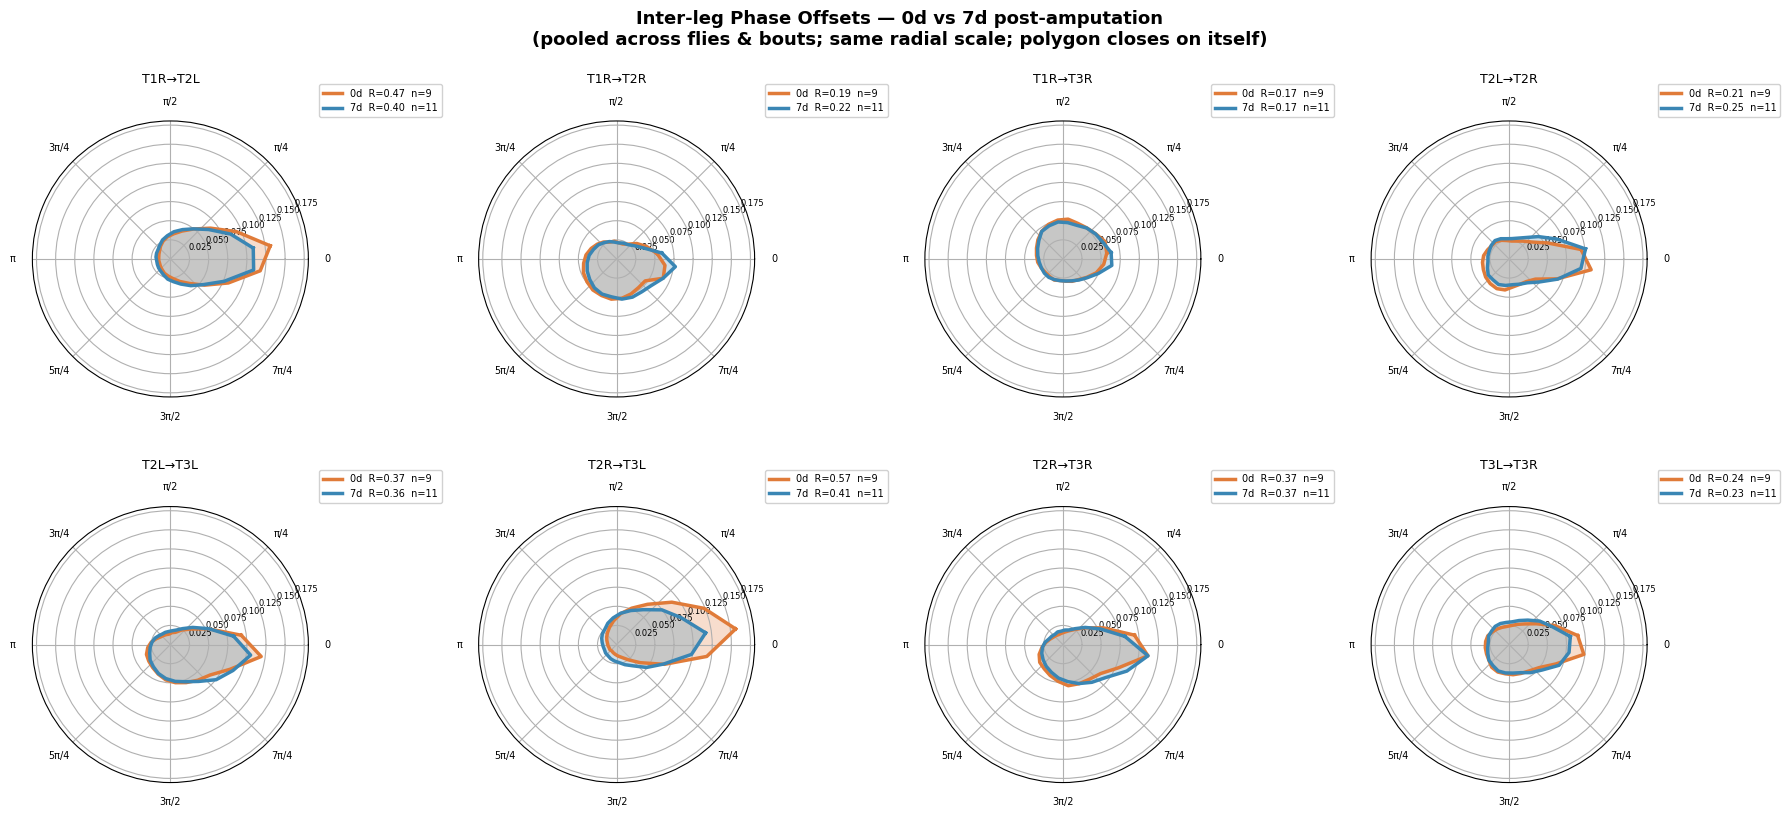

Phase offset polar plots complete.


In [8]:
# Cell 3a: Inter-leg phase offset distributions (polar histograms)
#
# Changes vs original:
#   • Fly colours defined here (warm=0d, cool=7d, no shared colours)
#   • Both conditions overlaid on the same polar axis per pair
#   • Individual fly traces removed; only mean polygon shown
#   • Polygon closes on itself (first bin appended at end)
#   • Identical radial scale across all subplots

# ── Fly colour assignment (used in Sections 3 & 4) ────────────────────────
# 0d flies → warm palette; 7d flies → cool palette; no overlap
_PAL_0D = ['#C0392B', '#E67E22', '#F39C12', '#8E44AD', '#D35400',
           '#922B21', '#BA4A00', '#7D3C98', '#B7950B', '#6E2F1A']
_PAL_7D = ['#1A5276', '#117A65', '#1F618D', '#145A32', '#1B4F72',
           '#0E6655', '#2E86C1', '#27AE60', '#2874A6', '#196F3D']

fly_colors = {}
for _cond, _pal in [('0d', _PAL_0D), ('7d', _PAL_7D)]:
    for _i, _fly in enumerate(all_results[_cond]):
        fly_colors[_fly['fly_id']] = _pal[_i % len(_pal)]

print(f"Fly colours assigned: {len(fly_colors)} flies")
for fid, col in fly_colors.items():
    print(f"  {fid[:40]:40s}  {col}")

# ── Helper ─────────────────────────────────────────────────────────────────
def _pool_phases_per_fly(fly_results):
    """Pool phase arrays across all bouts for one fly."""
    pooled = {}
    for bout in fly_results['bouts']:
        for pair_key, phases in bout['phase_offsets'].items():
            if len(phases) > 0:
                pooled.setdefault(pair_key, []).append(phases)
    return {k: np.concatenate(v) for k, v in pooled.items()}

# ── Collect all pair keys ──────────────────────────────────────────────────
all_pair_keys = sorted({
    k
    for cond in ['0d', '7d']
    for fly  in all_results[cond]
    for bout in fly['bouts']
    for k    in bout['phase_offsets'].keys()
})
print(f"\nPhase pairs found: {all_pair_keys}")

n_pairs  = len(all_pair_keys)
if n_pairs == 0:
    print("No phase data available — skipping phase plots.")
else:
    n_bins      = 24
    bin_edges   = np.linspace(0, 2 * np.pi, n_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    # ── Pass 1: compute all pooled histograms, find global max radius ──────
    hist_cache  = {}   # (pair_idx, cond) → (counts_norm, n_flies, R) or None
    global_rmax = 0.0

    for pair_idx, pair_key in enumerate(all_pair_keys):
        for cond in ['0d', '7d']:
            phase_lists, n_with = [], 0
            for fly in all_results[cond]:
                ph = _pool_phases_per_fly(fly).get(pair_key, np.array([]))
                if len(ph) > 0:
                    phase_lists.append(ph)
                    n_with += 1
            if phase_lists:
                all_ph      = np.concatenate(phase_lists)
                counts, _   = np.histogram(all_ph, bins=bin_edges)
                counts_norm = counts / counts.sum()
                R           = mean_resultant_length(all_ph)
                hist_cache[(pair_idx, cond)] = (counts_norm, n_with, R)
                global_rmax = max(global_rmax, counts_norm.max())
            else:
                hist_cache[(pair_idx, cond)] = None

    rmax = global_rmax * 1.15 if global_rmax > 0 else 0.1

    # ── Pass 2: draw ───────────────────────────────────────────────────────
    n_cols    = min(4, n_pairs)
    n_rows    = int(np.ceil(n_pairs / n_cols))
    fig, axes = plt.subplots(
        n_rows, n_cols,
        subplot_kw={'projection': 'polar'},
        figsize=(4.5 * n_cols, 4.2 * n_rows),
    )
    axes_flat = np.array(axes).reshape(-1) if n_pairs > 1 else np.array([axes])

    for pair_idx, pair_key in enumerate(all_pair_keys):
        ax = axes_flat[pair_idx]
        has_data = False
        for cond in ['0d', '7d']:
            data = hist_cache[(pair_idx, cond)]
            if data is None:
                continue
            counts_norm, n_with, R = data
            color = CFG[f'color_{cond}']
            # Close the polygon: repeat first bin at the end
            bc_cl = np.r_[bin_centers, [bin_centers[0]]]
            cn_cl = np.r_[counts_norm, [counts_norm[0]]]
            ax.plot(bc_cl, cn_cl, color=color, lw=2.5,
                    label=f'{cond}  R={R:.2f}  n={n_with}')
            ax.fill(bc_cl, cn_cl, color=color, alpha=0.25)
            has_data = True

        # Identical radial scale across all subplots
        ax.set_ylim(0, rmax)
        ax.yaxis.set_tick_params(labelsize=6)
        ax.set_xticks(np.linspace(0, 2 * np.pi, 8, endpoint=False))
        ax.set_xticklabels(
            ['0', 'π/4', 'π/2', '3π/4', 'π', '5π/4', '3π/2', '7π/4'],
            fontsize=7,
        )
        ax.set_title(pair_key, fontsize=9, pad=10)
        if has_data:
            ax.legend(fontsize=7, loc='upper right',
                      bbox_to_anchor=(1.5, 1.15), framealpha=0.9)

    for i in range(n_pairs, len(axes_flat)):
        axes_flat[i].set_visible(False)

    fig.suptitle(
        'Inter-leg Phase Offsets — 0d vs 7d post-amputation\n'
        '(pooled across flies & bouts; same radial scale; polygon closes on itself)',
        fontsize=13, fontweight='bold',
    )
    plt.tight_layout()
    plt.show()
    print("Phase offset polar plots complete.")


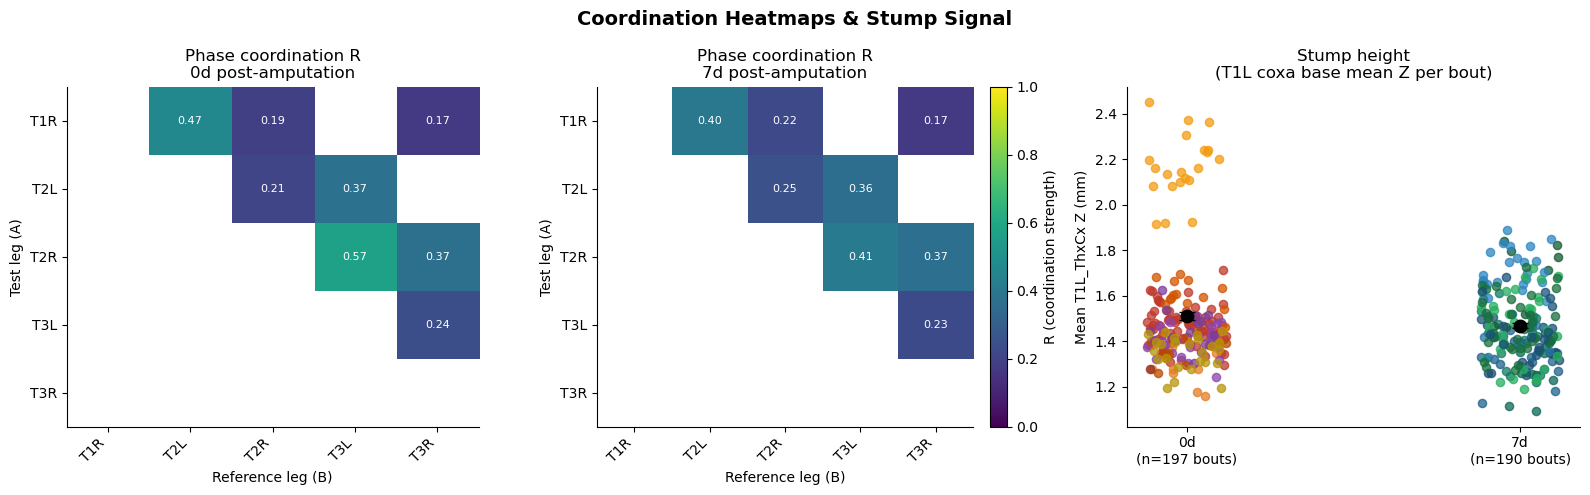

Coordination heatmaps complete.


In [9]:
# Cell 3b: Coordination summary heatmap + stump signal

LEG_ORDER = ['T1R', 'T2L', 'T2R', 'T3L', 'T3R']
TIP_ORDER = [f"{l}_TaTip" for l in LEG_ORDER]

def _build_rl_matrix(all_results_cond):
    """Build 5×5 mean-resultant-length matrix for a single condition."""
    mat = np.full((5, 5), np.nan)
    for i, tipA in enumerate(TIP_ORDER):
        for j, tipB in enumerate(TIP_ORDER):
            if i == j:
                continue
            labelA = tipA.replace('_TaTip', '')
            labelB = tipB.replace('_TaTip', '')
            pair_key = f"{labelA}→{labelB}"
            all_phases = []
            for fly in all_results_cond:
                for bout in fly['bouts']:
                    ph = bout['phase_offsets'].get(pair_key, np.array([]))
                    if len(ph) > 0:
                        all_phases.append(ph)
            if all_phases:
                concat = np.concatenate(all_phases)
                mat[i, j] = mean_resultant_length(concat)
    return mat


mat_0d = _build_rl_matrix(all_results['0d'])
mat_7d = _build_rl_matrix(all_results['7d'])

fig, axes = plt.subplots(1, 3, figsize=(16, 5),
                         gridspec_kw={'width_ratios': [1, 1, 1.1]})

for ax, mat, title in zip(axes[:2], [mat_0d, mat_7d], ['0d post-amputation', '7d post-amputation']):
    im = ax.imshow(mat, vmin=0, vmax=1, cmap='viridis', aspect='auto')
    ax.set_xticks(range(5))
    ax.set_yticks(range(5))
    ax.set_xticklabels(LEG_ORDER, rotation=45, ha='right')
    ax.set_yticklabels(LEG_ORDER)
    ax.set_xlabel('Reference leg (B)')
    ax.set_ylabel('Test leg (A)')
    ax.set_title(f'Phase coordination R\n{title}')
    for i in range(5):
        for j in range(5):
            if not np.isnan(mat[i, j]):
                ax.text(j, i, f"{mat[i,j]:.2f}", ha='center', va='center',
                        fontsize=8, color='white' if mat[i, j] < 0.6 else 'black')
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04, label='R (coordination strength)')

# --- Stump panel: mean Z per bout, strip + mean±SEM, coloured by fly ---
# Interpretation: absolute resting height of the stump coxa base.
# Each dot = one walking bout; colour = fly identity (same palette as Sections 3–4).
np.random.seed(42)
ax_stump = axes[2]

n_bouts_stump = {'0d': 0, '7d': 0}
for x_pos, cond in enumerate(['0d', '7d']):
    all_vals = []
    for fly in all_results[cond]:
        color = fly_colors.get(fly['fly_id'], '#888888')
        bout_means = [float(np.nanmean(b['stump_z']))
                      for b in fly['bouts'] if len(b['stump_z']) > 0]
        if bout_means:
            jitter = np.random.uniform(-0.12, 0.12, size=len(bout_means))
            ax_stump.scatter(x_pos + jitter, bout_means,
                             color=color, alpha=0.75, s=35, zorder=3)
            all_vals.extend(bout_means)
            n_bouts_stump[cond] += len(bout_means)
    if all_vals:
        m = float(np.nanmean(all_vals))
        e = float(sem(all_vals)) if len(all_vals) > 1 else 0.0
        ax_stump.errorbar(x_pos, m, yerr=e,
                          fmt='o', color='black', ms=9,
                          capsize=6, lw=2.2, zorder=5)

ax_stump.set_xticks([0, 1])
ax_stump.set_xticklabels([
    f'0d\n(n={n_bouts_stump["0d"]} bouts)',
    f'7d\n(n={n_bouts_stump["7d"]} bouts)',
])
ax_stump.set_ylabel('Mean T1L_ThxCx Z (mm)')
ax_stump.set_title('Stump height\n(T1L coxa base mean Z per bout)')

fig.suptitle('Coordination Heatmaps & Stump Signal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("Coordination heatmaps complete.")

## Section 4 — Fall Analysis

In [10]:
# Re-detect falls from stored head_z — run this whenever fall parameters change.
# No need to re-run batch processing; uses head_z arrays already in all_results.

for cond in ['0d', '7d']:
    for fly in all_results[cond]:
        fps = CFG['fps']
        for bout in fly['bouts']:
            head_z = bout.get('head_z')
            if head_z is None or len(head_z) == 0:
                continue
            fall_peaks, fall_proms, fall_widths = detect_falls(head_z, CFG)
            dur_s = bout['n_frames'] / fps
            bout['fall_frames_in_bout'] = fall_peaks
            bout['fall_depths']         = fall_proms
            bout['fall_widths_frames']  = fall_widths
            bout['n_falls']             = len(fall_peaks)
            bout['fall_rate_per_s']     = len(fall_peaks) / dur_s if dur_s > 0 else 0.0
            # Also refresh tripod-phase-at-falls if swing data is present
            sw = bout.get('swing_dict', {})
            if sw:
                tripod_state = build_right_tripod_state(sw, fps)
                bout['tripod_phase_at_falls'] = phase_at_falls(fall_peaks, tripod_state)

total_falls = sum(
    b['n_falls']
    for cond in ['0d', '7d']
    for fly   in all_results[cond]
    for b     in fly['bouts']
)
print(f"Falls re-detected  prominence≥{CFG['fall_prominence_mm']} mm  "
      f"duration≥{CFG['fall_min_duration_frames']} frames")
print(f"Total falls across all flies/bouts: {total_falls}")


Falls re-detected  prominence≥0.25 mm  duration≥20 frames
Total falls across all flies/bouts: 1768


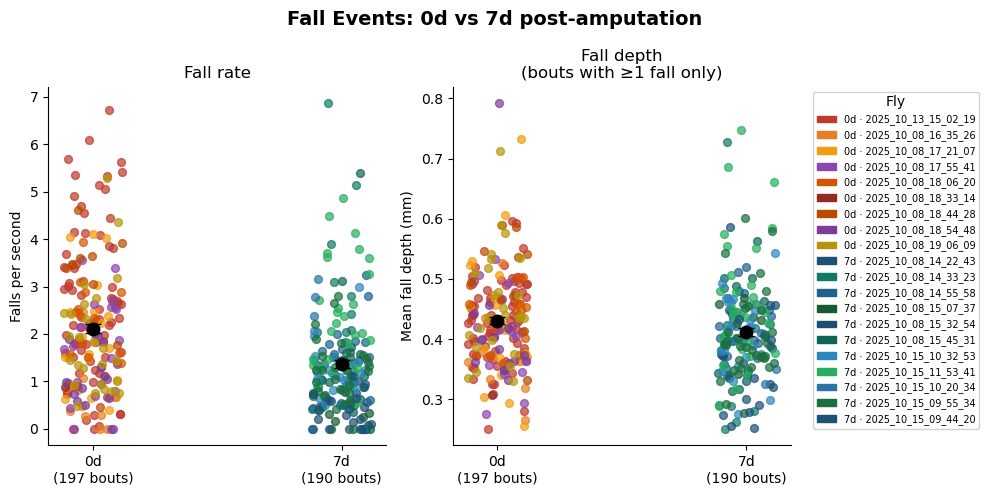

Fall rate and depth strip plots complete.


In [11]:
# Cell 4a: Fall rate and fall depth — strip + mean±SEM, coloured by fly
# Each dot = one walking bout; colour = fly identity (consistent with Section 3).

np.random.seed(42)


def _strip_plot_per_fly(ax, all_results_dict, fly_colors_dict,
                        ylabel, title, get_val_fn):
    """Strip plot with per-fly coloured dots and black mean±SEM error bar.

    Args:
        get_val_fn: callable(bout) → float or None; returns the metric for one bout.
    """
    for x_pos, cond in enumerate(['0d', '7d']):
        all_vals = []
        for fly in all_results_dict[cond]:
            color     = fly_colors_dict.get(fly['fly_id'], '#888888')
            fly_vals  = [v for v in (get_val_fn(b) for b in fly['bouts'])
                         if v is not None and not np.isnan(v)]
            if fly_vals:
                jitter = np.random.uniform(-0.12, 0.12, size=len(fly_vals))
                ax.scatter(x_pos + jitter, fly_vals,
                           color=color, alpha=0.7, s=32, zorder=3)
                all_vals.extend(fly_vals)
        if all_vals:
            m = float(np.nanmean(all_vals))
            e = float(sem(all_vals)) if len(all_vals) > 1 else 0.0
            ax.errorbar(x_pos, m, yerr=e, fmt='o', color='black',
                        ms=9, capsize=6, lw=2.2, zorder=5)

    n0_bouts = sum(f['n_bouts'] for f in all_results_dict['0d'])
    n7_bouts = sum(f['n_bouts'] for f in all_results_dict['7d'])
    ax.set_xticks([0, 1])
    ax.set_xticklabels([f'0d\n({n0_bouts} bouts)', f'7d\n({n7_bouts} bouts)'])
    ax.set_ylabel(ylabel)
    ax.set_title(title)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

_strip_plot_per_fly(
    ax1, all_results, fly_colors,
    'Falls per second', 'Fall rate',
    get_val_fn=lambda b: b['fall_rate_per_s'],
)

_strip_plot_per_fly(
    ax2, all_results, fly_colors,
    'Mean fall depth (mm)', 'Fall depth\n(bouts with ≥1 fall only)',
    get_val_fn=lambda b: float(np.mean(b['fall_depths'])) if len(b['fall_depths']) > 0 else None,
)

# Per-fly colour legend
from matplotlib.patches import Patch as _Patch
legend_handles = []
for _cond in ['0d', '7d']:
    for _fly in all_results[_cond]:
        _fid   = _fly['fly_id']
        _label = f"{_cond} · {_fid.split('/')[-1]}"
        legend_handles.append(_Patch(color=fly_colors[_fid], label=_label))
ax2.legend(handles=legend_handles, title='Fly', fontsize=7,
           bbox_to_anchor=(1.05, 1), loc='upper left', framealpha=0.9)

fig.suptitle('Fall Events: 0d vs 7d post-amputation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("Fall rate and depth strip plots complete.")


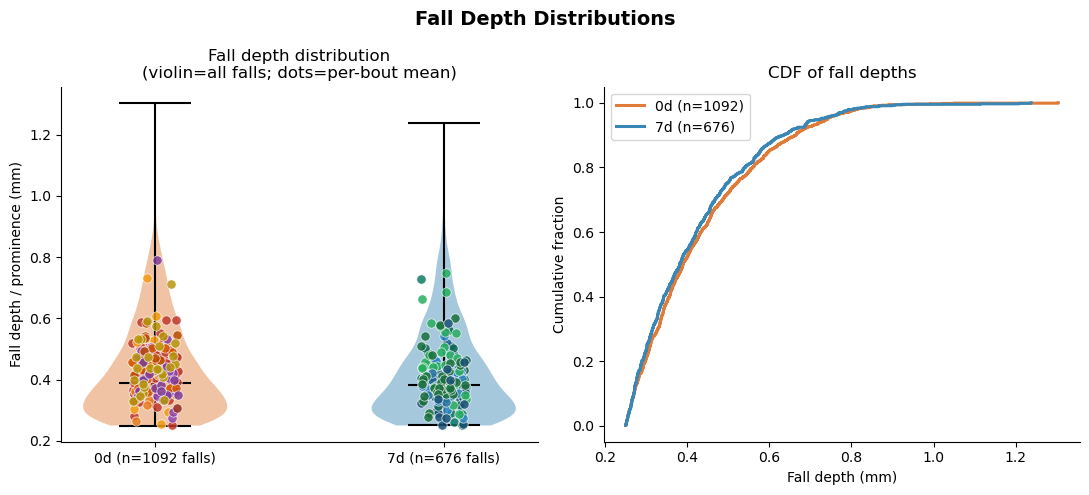

Fall depth distributions complete.


In [12]:
# Cell 4b: Fall depth distribution — violin (condition) + per-fly dots + CDF

np.random.seed(42)

# Collect all individual fall prominences per condition
all_depths = {}
for cond in ['0d', '7d']:
    depths = []
    for fly in all_results[cond]:
        for bout in fly['bouts']:
            depths.extend(bout['fall_depths'].tolist())
    all_depths[cond] = np.array(depths)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))

# --- Violin ---
ax1_data = [all_depths['0d'], all_depths['7d']]
valid_data = [d for d in ax1_data if len(d) > 0]
positions  = [i for i, d in enumerate(ax1_data) if len(d) > 0]

if valid_data:
    parts = ax1.violinplot(valid_data, positions=positions, showmedians=True)
    for body, pos in zip(parts['bodies'], positions):
        cond = ['0d', '7d'][pos]
        body.set_facecolor(CFG[f'color_{cond}'])
        body.set_alpha(0.45)
    for part in ['cmedians', 'cbars', 'cmins', 'cmaxes']:
        if part in parts:
            parts[part].set_color('black')

# Per-fly dots: one dot per bout (mean fall depth), overlaid on violin
for x_pos, cond in enumerate(['0d', '7d']):
    for fly in all_results[cond]:
        color = fly_colors.get(fly['fly_id'], '#888888')
        bout_means = [float(np.mean(b['fall_depths']))
                      for b in fly['bouts'] if len(b['fall_depths']) > 0]
        if bout_means:
            jitter = np.random.uniform(-0.08, 0.08, size=len(bout_means))
            ax1.scatter(x_pos + jitter, bout_means,
                        color=color, s=45, alpha=0.85, zorder=5,
                        edgecolor='white', linewidth=0.5)

ax1.set_xticks([0, 1])
ax1.set_xticklabels([
    f'0d (n={len(all_depths["0d"])} falls)',
    f'7d (n={len(all_depths["7d"])} falls)',
])
ax1.set_ylabel('Fall depth / prominence (mm)')
ax1.set_title('Fall depth distribution\n(violin=all falls; dots=per-bout mean)')

# --- CDF ---
for cond in ['0d', '7d']:
    d = np.sort(all_depths[cond])
    if len(d) > 0:
        cdf = np.arange(1, len(d) + 1) / len(d)
        ax2.step(d, cdf, where='post', color=CFG[f'color_{cond}'],
                 lw=2.2, label=f"{cond} (n={len(d)})")
ax2.set_xlabel('Fall depth (mm)')
ax2.set_ylabel('Cumulative fraction')
ax2.set_title('CDF of fall depths')
ax2.legend()

fig.suptitle('Fall Depth Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("Fall depth distributions complete.")


NameError: name '_get_swing_onsets' is not defined

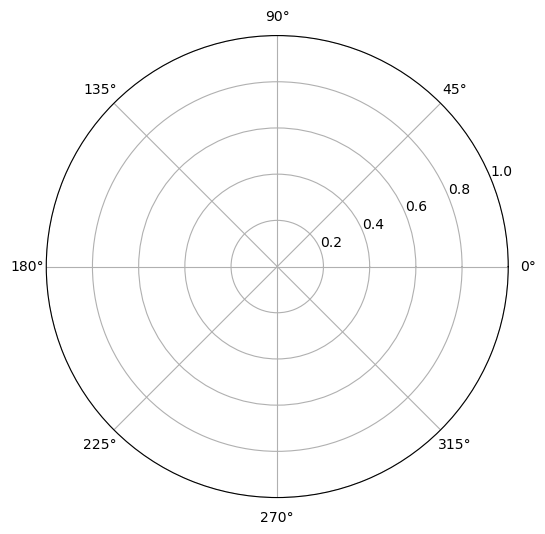

In [13]:
# Cell 4c: Phase of fall — polar histogram relative to right-tripod cycle
#
# We express the timing of each fall event as a phase in [0, 2π) relative
# to the right-tripod swing cycle (T1R–T2L–T3R).

def _fall_phases_relative_to_tripod(all_results_cond, fps):
    """For each fall event, compute its phase in the right-tripod cycle [0, 2π).

    Uses T1R_TaTip swing onsets as the reference clock.

    Returns:
        phases: 1-D array of phases (radians).
    """
    phases = []
    for fly in all_results_cond:
        for bout in fly['bouts']:
            fall_frames = bout.get('fall_frames_in_bout', [])
            if len(fall_frames) == 0:
                continue
            swing_dict = bout.get('swing_dict', {})
            t1r_key = 'T1R_TaTip'
            if t1r_key not in swing_dict:
                continue
            t1r_onsets = _get_swing_onsets(swing_dict[t1r_key])
            if len(t1r_onsets) < 2:
                continue
            # Compute phase of each fall relative to T1R cycle
            ph = compute_phase_offset(np.array(fall_frames, dtype=int), t1r_onsets, fps)
            phases.append(ph)
    return np.concatenate(phases) if phases else np.array([])


n_bins = 24
bin_edges = np.linspace(0, 2 * np.pi, n_bins + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={'projection': 'polar'})

for cond in ['0d', '7d']:
    phases = _fall_phases_relative_to_tripod(all_results[cond], CFG['fps'])
    color  = CFG[f'color_{cond}']
    if len(phases) > 0:
        counts, _ = np.histogram(phases, bins=bin_edges)
        counts_norm = counts / max(counts.sum(), 1)
        ax.plot(bin_centers, counts_norm, color=color, lw=2.5,
                label=f"{cond} (n={len(phases)} falls)")
        ax.fill(bin_centers, counts_norm, color=color, alpha=0.2)
        # Mark mean direction
        cm = circmean(phases)
        R  = mean_resultant_length(phases)
        ax.annotate('', xy=(cm, R * counts_norm.max()),
                    xytext=(0, 0),
                    arrowprops=dict(arrowstyle='->', color=color, lw=2))
    else:
        print(f"  No fall-phase data for {cond}")

ax.set_title('Phase of falls relative to\nT1R swing cycle', pad=20)
ax.set_xticks(np.linspace(0, 2 * np.pi, 8, endpoint=False))
ax.set_xticklabels(['0', 'π/4', 'π/2', '3π/4', 'π', '5π/4', '3π/2', '7π/4'])
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15))

plt.tight_layout()
plt.show()
print("Fall phase polar histogram complete.")

## Section 5 — Speed & Body Height Comparison

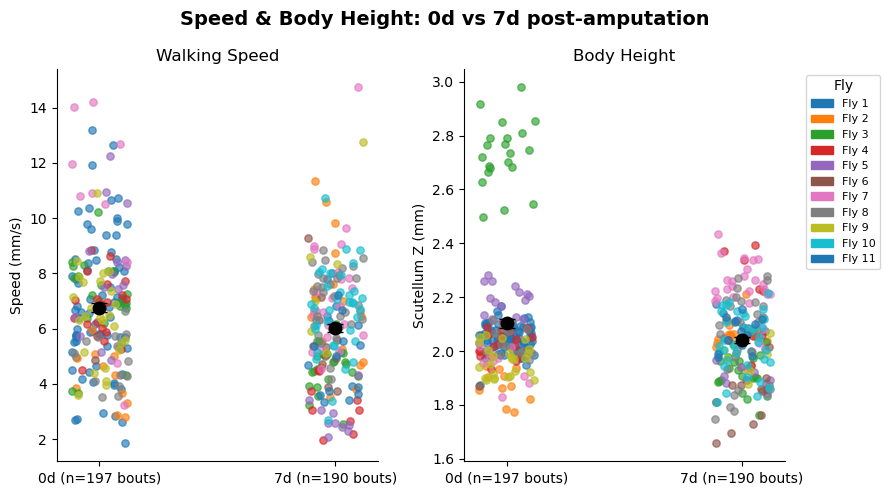

Speed and height comparison complete.


In [14]:
# Cell 5: Walking speed and body height — strip + mean±SEM

# Collect per-bout metrics, colour-coded by fly within condition
def _collect_with_fly_id(all_results_dict, metric_key):
    """Return {condition: list of (value, fly_idx)} tuples."""
    out = {}
    for cond in ['0d', '7d']:
        vals = []
        for fly_idx, fly in enumerate(all_results_dict[cond]):
            for bout in fly['bouts']:
                vals.append((bout[metric_key], fly_idx))
        out[cond] = vals
    return out


speed_data  = _collect_with_fly_id(all_results, 'speed_mm_s')
height_data = _collect_with_fly_id(all_results, 'mean_height_mm')

# Distinct colours per fly
fly_cmap = plt.cm.tab10

fig, (ax_speed, ax_height) = plt.subplots(1, 2, figsize=(9, 5))

for ax, data_dict, ylabel, title in [
    (ax_speed,  speed_data,  'Speed (mm/s)',       'Walking Speed'),
    (ax_height, height_data, 'Scutellum Z (mm)',   'Body Height'),
]:
    for x_pos, cond in enumerate(['0d', '7d']):
        entries = data_dict[cond]
        if not entries:
            continue
        vals     = np.array([v for v, _ in entries])
        fly_idxs = np.array([fi for _, fi in entries])
        jitter   = np.random.uniform(-0.12, 0.12, size=len(vals))
        for v, fi, j in zip(vals, fly_idxs, jitter):
            ax.scatter(x_pos + j, v,
                       color=fly_cmap(fi % 10), alpha=0.65, s=28, zorder=2)
        # Mean ± SEM
        m = np.nanmean(vals)
        e = sem(vals, nan_policy='omit') if len(vals) > 1 else 0.0
        ax.errorbar(x_pos, m, yerr=e, fmt='o', color='black',
                    ms=9, capsize=6, lw=2.2, zorder=4)

    ax.set_xticks([0, 1])
    ax.set_xticklabels([
        f"0d (n={len(data_dict['0d'])} bouts)",
        f"7d (n={len(data_dict['7d'])} bouts)",
    ])
    ax.set_ylabel(ylabel)
    ax.set_title(title)

# Legend: fly identity
n_flies_max = max(
    len(all_results['0d']), len(all_results['7d'])
)
handles = [Patch(color=fly_cmap(i % 10), label=f'Fly {i+1}') for i in range(n_flies_max)]
ax_height.legend(handles=handles, title='Fly', bbox_to_anchor=(1.05, 1), fontsize=8)

fig.suptitle('Speed & Body Height: 0d vs 7d post-amputation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("Speed and height comparison complete.")

## Section 6 — Representative Bout Visualization

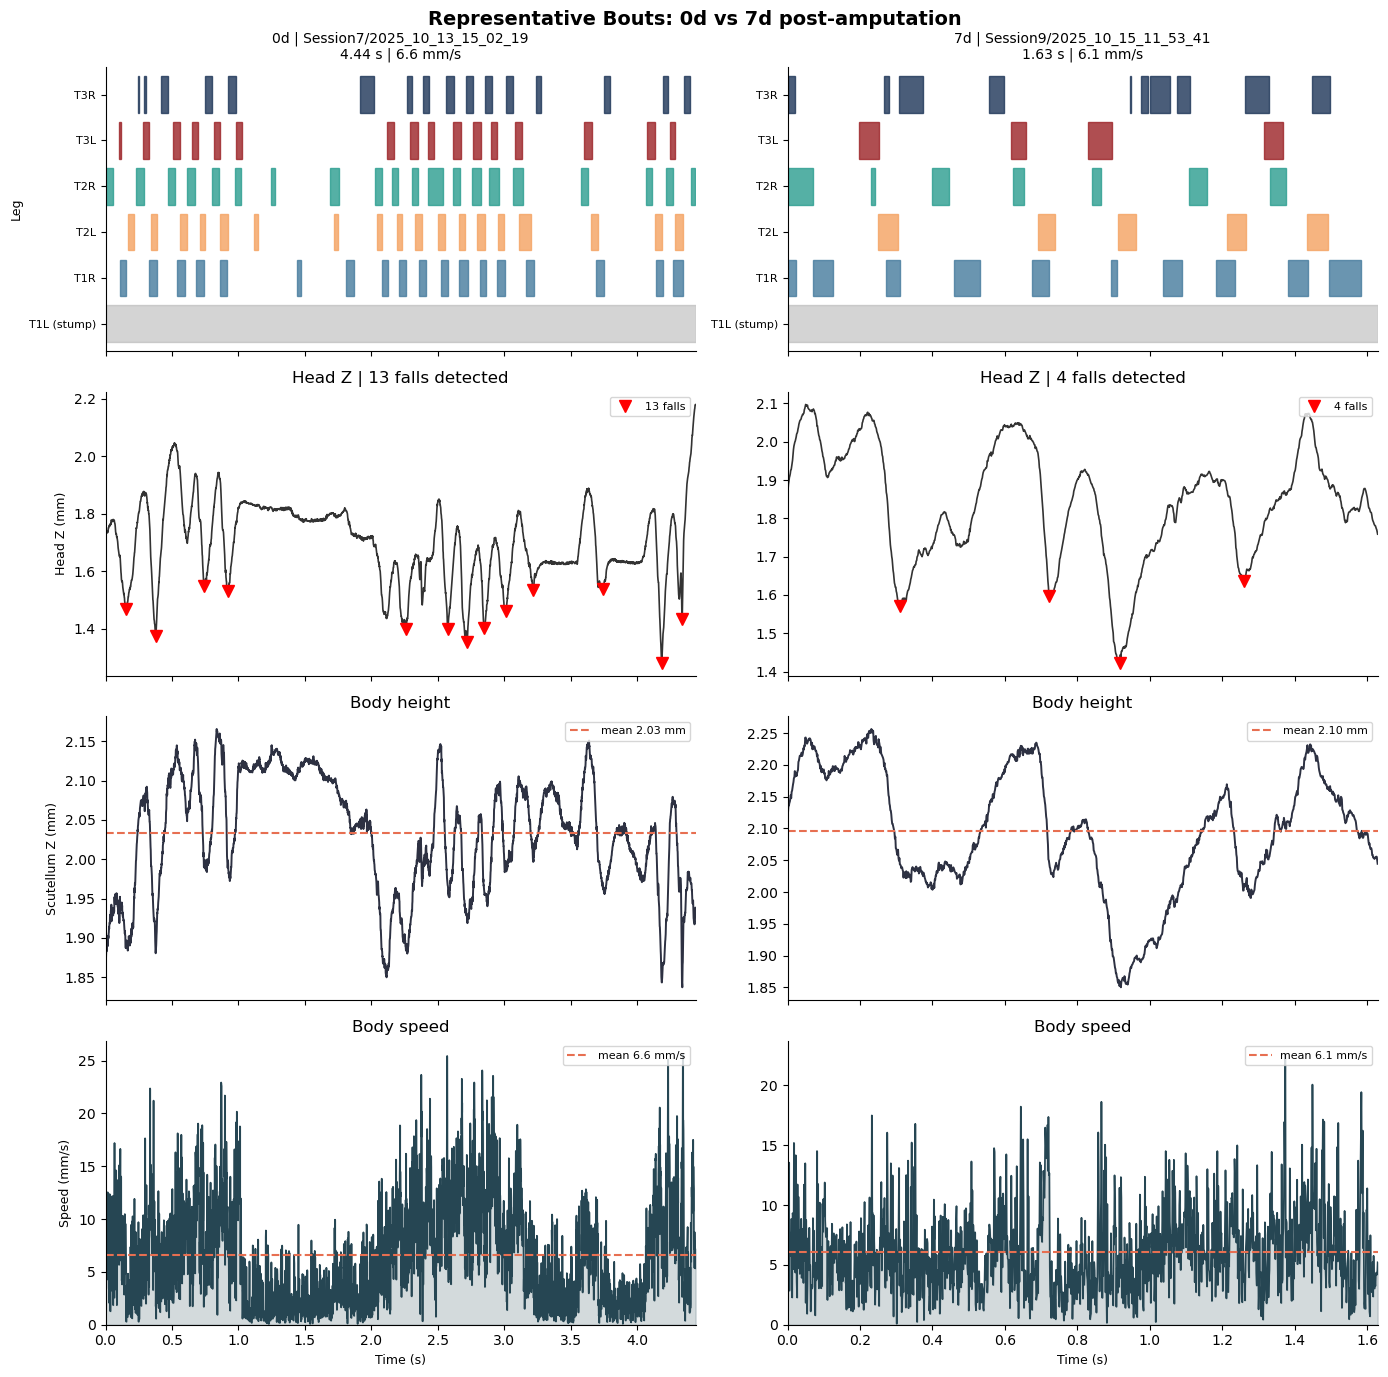

Representative bout visualisation complete.


In [15]:
# Cell 6: Representative bout visualisation (median-speed bout per condition)
#
# Rows: gait diagram | head Z (+ falls) | scutellum Z | body speed
# Columns: 0d | 7d

LEG_COLORS = {
    'T1R_TaTip': '#457B9D',
    'T2L_TaTip': '#F4A261',
    'T2R_TaTip': '#2A9D8F',
    'T3L_TaTip': '#9B2226',
    'T3R_TaTip': '#1D3557',
    'T1L_ThxCx': '#AAAAAA',  # stump — grey
}


def _pick_median_speed_bout(results_cond):
    """Select the bout with speed closest to the median across all bouts."""
    all_bouts = [(fly['fly_id'], bout) for fly in results_cond for bout in fly['bouts']]
    if not all_bouts:
        return None, None
    speeds = np.array([b['speed_mm_s'] for _, b in all_bouts])
    med_idx = int(np.argmin(np.abs(speeds - np.median(speeds))))
    return all_bouts[med_idx]  # (fly_id, bout_metrics)


fig, axes = plt.subplots(4, 2, figsize=(14, 14), sharex='col')
# axes rows: [gait, head_z, scut_z, speed]
# axes cols: [0d, 7d]

for col_idx, cond in enumerate(['0d', '7d']):
    fly_id, bout = _pick_median_speed_bout(all_results[cond])
    if bout is None:
        for row in range(4):
            axes[row, col_idx].text(0.5, 0.5, f'No data ({cond})',
                                    ha='center', va='center',
                                    transform=axes[row, col_idx].transAxes)
        continue

    n_frames  = bout['n_frames']
    fps       = CFG['fps']
    t_s       = np.arange(n_frames) / fps
    leg_order = list(CFG['intact_leg_tips'])  # T1R, T2L, T2R, T3L, T3R
    swing_dict = bout['swing_dict']

    # ---- Row 0: Gait phase diagram ----
    ax_gait = axes[0, col_idx]
    for y_pos, tip in enumerate(leg_order):
        sw = swing_dict.get(tip, np.zeros(n_frames))
        color = LEG_COLORS.get(tip, 'gray')
        # Shade swing (=1) regions
        in_swing = False
        for t in range(len(sw)):
            if sw[t] == 1 and not in_swing:
                sw_start = t
                in_swing = True
            elif sw[t] == 0 and in_swing:
                ax_gait.axhspan(y_pos - 0.4, y_pos + 0.4,
                                xmin=t_s[sw_start] / t_s[-1],
                                xmax=t_s[t - 1] / t_s[-1],
                                color=color, alpha=0.8)
                in_swing = False
        if in_swing:
            ax_gait.axhspan(y_pos - 0.4, y_pos + 0.4,
                            xmin=t_s[sw_start] / t_s[-1],
                            xmax=1.0,
                            color=color, alpha=0.8)

    # Stump bar at bottom (grey, always stance)
    stump_y = -1
    ax_gait.axhspan(stump_y - 0.4, stump_y + 0.4, color=LEG_COLORS['T1L_ThxCx'], alpha=0.5)
    ax_gait.set_yticks(list(range(len(leg_order))) + [stump_y])
    ax_gait.set_yticklabels(
        [t.replace('_TaTip', '') for t in leg_order] + ['T1L (stump)'],
        fontsize=8
    )
    ax_gait.set_xlim(t_s[0], t_s[-1])
    ax_gait.set_ylim(stump_y - 0.6, len(leg_order) - 0.4)
    ax_gait.set_title(f'{cond} | {fly_id}\n{n_frames/fps:.2f} s | {bout["speed_mm_s"]:.1f} mm/s',
                      fontsize=10)
    if col_idx == 0:
        ax_gait.set_ylabel('Leg', fontsize=9)

    # ---- Row 1: Head Z with fall events ----
    ax_head = axes[1, col_idx]
    head_z = bout['head_z']
    ax_head.plot(t_s, head_z, color='#333333', lw=1.2)
    fall_frames = bout['fall_frames_in_bout']
    if len(fall_frames) > 0:
        ax_head.plot(t_s[fall_frames], head_z[fall_frames], 'rv',
                     ms=8, zorder=5, label=f'{len(fall_frames)} falls')
        ax_head.legend(fontsize=8, loc='upper right')
    if col_idx == 0:
        ax_head.set_ylabel('Head Z (mm)', fontsize=9)
    ax_head.set_title('Head Z' + (f' | {len(fall_frames)} falls detected' if len(fall_frames) else ''))

    # ---- Row 2: Scutellum Z ----
    ax_scut = axes[2, col_idx]
    ax_scut.plot(t_s, bout['scutellum_z_bout'], color='#2D3142', lw=1.4)
    ax_scut.axhline(bout['mean_height_mm'], color='#E76F51', ls='--', lw=1.5,
                    label=f'mean {bout["mean_height_mm"]:.2f} mm')
    ax_scut.legend(fontsize=8, loc='upper right')
    if col_idx == 0:
        ax_scut.set_ylabel('Scutellum Z (mm)', fontsize=9)
    ax_scut.set_title('Body height')

    # ---- Row 3: Body speed ----
    ax_spd = axes[3, col_idx]
    ax_spd.plot(t_s, bout['speed_array'], color='#264653', lw=1.2)
    ax_spd.axhline(bout['speed_mm_s'], color='#E76F51', ls='--', lw=1.5,
                   label=f'mean {bout["speed_mm_s"]:.1f} mm/s')
    ax_spd.fill_between(t_s, 0, bout['speed_array'], alpha=0.2, color='#264653')
    ax_spd.legend(fontsize=8, loc='upper right')
    if col_idx == 0:
        ax_spd.set_ylabel('Speed (mm/s)', fontsize=9)
    ax_spd.set_xlabel('Time (s)', fontsize=9)
    ax_spd.set_title('Body speed')
    ax_spd.set_ylim(bottom=0)

fig.suptitle('Representative Bouts: 0d vs 7d post-amputation',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("Representative bout visualisation complete.")